# Zarr Chunk Size + Action Horizon Benchmark

This notebook benchmarks multiple Zarr datasets (with different chunk sizes) across various action horizons using dynamic chunking, and visualizes the results.

In [11]:
from pathlib import Path
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from egomimic.rldb.zarr.zarr_dataset import ZarrDataset, ZarrDatasetMetadata
from egomimic.rldb.zarr.benchmark_forward_pass import benchmark_dataloader, safe_collate

In [12]:
# Zarr folders to benchmark (edit these paths)
ZARR_FOLDERS = [
    f"/home/ryan/Code/EgoVerse/egomimic/rldb/zarr/zarr/dynamic/{i}mb" 
    for i in range(1, 9)
]

# Action horizons to test
ACTION_HORIZONS = [10, 50, 100, 250, 500]

# Benchmark parameters
BATCH_SIZE = 32
NUM_WORKERS = 10
NUM_SAMPLES = 10000
WARMUP = 10
PREFETCH_FACTOR = 2

# Action keys for dynamic chunking
ACTION_KEYS = ["actions_base_cartesian", "actions_cartesian", "actions_eef_cartesian", "actions_joints"]

In [13]:
def parse_chunk_size(folder_name: str) -> int | None:
    # Looks for a number followed by 'mb' (case-insensitive)
    match = re.search(r'(\d+)mb', folder_name, re.IGNORECASE)
    if match:
        return int(match.group(1))
    return None


def build_delta_timestamps(fps: int, horizon: int, action_keys: list[str]) -> dict[str, list[float]]:
    """Create temporal config for dynamic action chunking.
    
    Args:
        fps: Frames per second of the dataset
        horizon: Number of future action timesteps to load
        action_keys: List of action keys to apply chunking to
    
    Returns:
        Dict mapping action keys to time offsets [0.0, 1/fps, 2/fps, ..., (horizon-1)/fps]
    """
    time_offsets = [i / fps for i in range(horizon)]
    return {key: time_offsets for key in action_keys}


def run_single_benchmark(
    zarr_path: str | Path,
    horizon: int,
    action_keys: list[str],
    batch_size: int = 32,
    num_workers: int = 10,
    num_samples: int = 5000,
    warmup: int = 10,
    prefetch_factor: int = 2,
) -> dict:
    """Benchmark one configuration (zarr path + action horizon).
    
    Args:
        zarr_path: Path to the Zarr dataset
        horizon: Action horizon (number of future timesteps)
        action_keys: Action keys for dynamic chunking
        batch_size: Batch size for DataLoader
        num_workers: Number of DataLoader workers
        num_samples: Number of samples to benchmark
        warmup: Warmup iterations
        prefetch_factor: DataLoader prefetch factor
    
    Returns:
        Dict with benchmark results
    """
    zarr_path = Path(zarr_path)
    
    # Load metadata to get FPS
    meta = ZarrDatasetMetadata(repo_id=zarr_path.name, root=zarr_path)
    fps = meta.fps if hasattr(meta, 'fps') else 30
    
    # Build delta_timestamps for dynamic chunking
    delta_timestamps = build_delta_timestamps(fps, horizon, action_keys)
    
    # Create dataset with dynamic chunking
    dataset = ZarrDataset(
        repo_id=zarr_path.name,
        root=zarr_path,
        delta_timestamps=delta_timestamps,
    )
    
    # Run benchmark
    results = benchmark_dataloader(
        dataset=dataset,
        num_samples=min(num_samples, len(dataset)),
        batch_size=batch_size,
        num_workers=num_workers,
        warmup=warmup,
        prefetch_factor=prefetch_factor,
        collate_fn=safe_collate,
    )
    
    return results

In [ ]:
# Run all benchmarks
results = []

total_configs = len(ZARR_FOLDERS) * len(ACTION_HORIZONS)
pbar = tqdm(total=total_configs, desc="Running benchmarks")

for zarr_folder in ZARR_FOLDERS:
    zarr_path = Path(zarr_folder)
    chunk_size = parse_chunk_size(zarr_path.name)
    
    if chunk_size is None:
        print(f"Warning: Could not parse chunk size from '{zarr_path.name}', using folder name as label")
        chunk_label = zarr_path.name
    else:
        chunk_label = chunk_size
    
    for horizon in ACTION_HORIZONS:
        pbar.set_description(f"Chunk={chunk_label}, Horizon={horizon}")
        
        try:
            benchmark_results = run_single_benchmark(
                zarr_path=zarr_path,
                horizon=horizon,
                action_keys=ACTION_KEYS,
                batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS,
                num_samples=NUM_SAMPLES,
                warmup=WARMUP,
                prefetch_factor=PREFETCH_FACTOR,
            )
            
            results.append({
                "chunk_size": chunk_label,
                "action_horizon": horizon,
                "throughput_samples_sec": benchmark_results["throughput_samples_sec"],
                "batches_per_sec": benchmark_results["batches_per_sec"],
                "avg_time_per_batch_ms": benchmark_results["avg_time_per_batch"] * 1000,
                "total_time_sec": benchmark_results["total_time_sec"],
                "samples_processed": benchmark_results["samples_processed"],
            })
        except Exception as e:
            print(f"Error benchmarking {zarr_path} with horizon {horizon}: {e}")
            results.append({
                "chunk_size": chunk_label,
                "action_horizon": horizon,
                "throughput_samples_sec": None,
                "batches_per_sec": None,
                "avg_time_per_batch_ms": None,
                "total_time_sec": None,
                "samples_processed": None,
            })
        
        pbar.update(1)

pbar.close()
print(f"\nCompleted {len(results)} benchmark configurations")

Running benchmarks:   0%|          | 0/40 [00:00<?, ?it/s]

  Warming up with 10 batches...
  Benchmarking 313 batches (batch_size=32, workers=10, prefetch=2)...
    Progress: 31/313 (10%)
    Progress: 62/313 (20%)
    Progress: 93/313 (30%)
    Progress: 124/313 (40%)
    Progress: 155/313 (50%)
    Progress: 186/313 (59%)
    Progress: 217/313 (69%)
    Progress: 248/313 (79%)
    Progress: 279/313 (89%)
    Progress: 310/313 (99%)
    Progress: 313/313 (100%)
  Warming up with 10 batches...
  Benchmarking 313 batches (batch_size=32, workers=10, prefetch=2)...
    Progress: 31/313 (10%)
    Progress: 62/313 (20%)
    Progress: 93/313 (30%)
    Progress: 124/313 (40%)
    Progress: 155/313 (50%)
    Progress: 186/313 (59%)
    Progress: 217/313 (69%)
    Progress: 248/313 (79%)
    Progress: 279/313 (89%)
    Progress: 310/313 (99%)
    Progress: 313/313 (100%)
  Warming up with 10 batches...
  Benchmarking 313 batches (batch_size=32, workers=10, prefetch=2)...
    Progress: 31/313 (10%)
    Progress: 62/313 (20%)
    Progress: 93/313 (30%)
 

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x745b877f8540>
Traceback (most recent call last):
  File "/home/ryan/Code/EgoVerse/emimic/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/home/ryan/Code/EgoVerse/emimic/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1582, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.11/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 935, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/selectors.py", line 415, in select
    fd_event

  Warming up with 10 batches...
  Benchmarking 313 batches (batch_size=32, workers=10, prefetch=2)...


In [ ]:
# Create results DataFrame
df = pd.DataFrame(results)
print("Raw Results:")
display(df)

# Pivot tables for different metrics
print("\n=== Throughput (samples/sec) ===")
throughput_pivot = df.pivot_table(
    values="throughput_samples_sec",
    index="chunk_size",
    columns="action_horizon",
    aggfunc="first"
)
display(throughput_pivot.round(1))

print("\n=== Average Batch Time (ms) ===")
batch_time_pivot = df.pivot_table(
    values="avg_time_per_batch_ms",
    index="chunk_size",
    columns="action_horizon",
    aggfunc="first"
)
display(batch_time_pivot.round(2))

print("\n=== Batches per Second ===")
batches_pivot = df.pivot_table(
    values="batches_per_sec",
    index="chunk_size",
    columns="action_horizon",
    aggfunc="first"
)
display(batches_pivot.round(1))

Raw Results:


,chunk_size,action_horizon,throughput_samples_sec,batches_per_sec,avg_time_per_batch_ms,total_time_sec,samples_processed
0,32,15,None,None,None,None,None
1,32,30,None,None,None,None,None
2,32,45,None,None,None,None,None
3,32,60,None,None,None,None,None
4,32,90,None,None,None,None,None
5,64,15,None,None,None,None,None
6,64,30,None,None,None,None,None
7,64,45,None,None,None,None,None
8,64,60,None,None,None,None,None
9,64,90,None,None,None,None,None



=== Throughput (samples/sec) ===


action_horizon
chunk_size



=== Average Batch Time (ms) ===


action_horizon
chunk_size



=== Batches per Second ===


action_horizon
chunk_size


TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

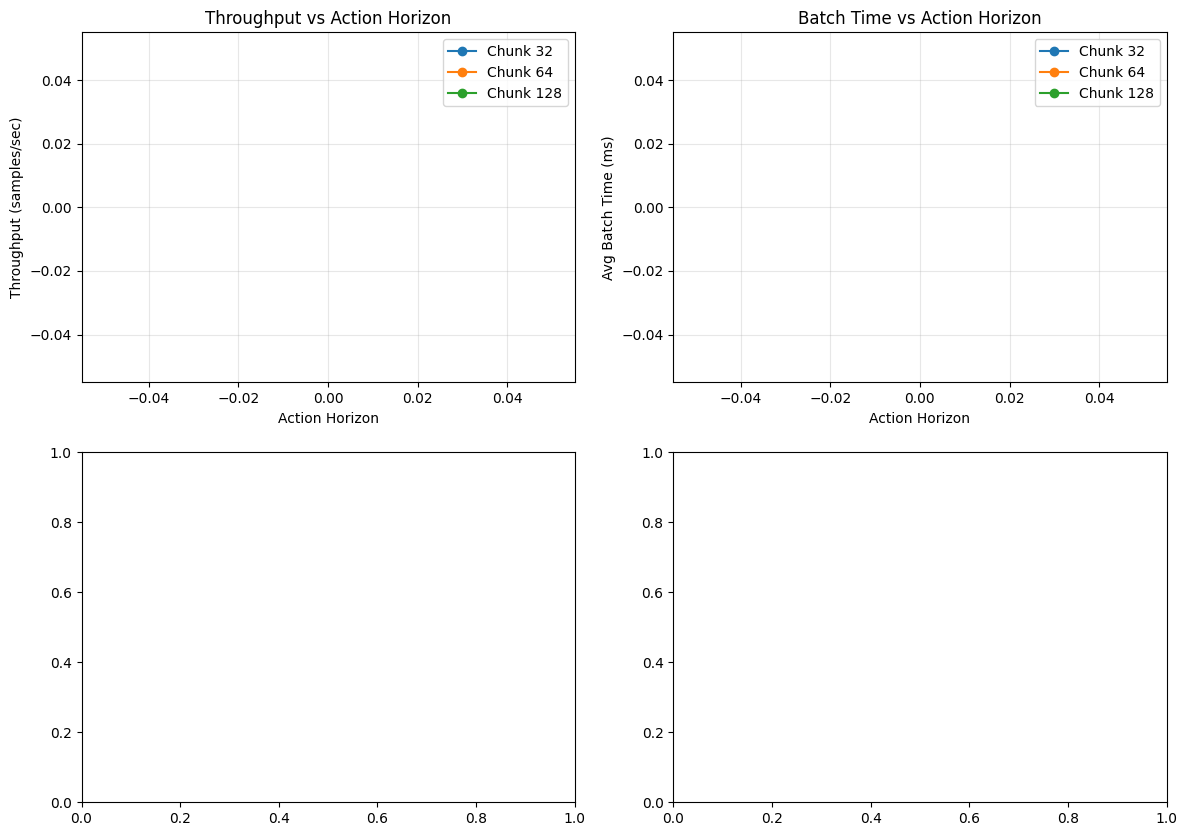

In [ ]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get unique chunk sizes
chunk_sizes = df["chunk_size"].unique()
colors = plt.cm.tab10(range(len(chunk_sizes)))
chunk_color_map = {cs: colors[i] for i, cs in enumerate(chunk_sizes)}

# Plot 1: Throughput vs Action Horizon (line plot)
ax1 = axes[0, 0]
for chunk_size in chunk_sizes:
    chunk_df = df[df["chunk_size"] == chunk_size].sort_values("action_horizon")
    ax1.plot(
        chunk_df["action_horizon"],
        chunk_df["throughput_samples_sec"],
        marker="o",
        label=f"Chunk {chunk_size}",
        color=chunk_color_map[chunk_size],
    )
ax1.set_xlabel("Action Horizon")
ax1.set_ylabel("Throughput (samples/sec)")
ax1.set_title("Throughput vs Action Horizon")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Avg Batch Time vs Action Horizon (line plot)
ax2 = axes[0, 1]
for chunk_size in chunk_sizes:
    chunk_df = df[df["chunk_size"] == chunk_size].sort_values("action_horizon")
    ax2.plot(
        chunk_df["action_horizon"],
        chunk_df["avg_time_per_batch_ms"],
        marker="o",
        label=f"Chunk {chunk_size}",
        color=chunk_color_map[chunk_size],
    )
ax2.set_xlabel("Action Horizon")
ax2.set_ylabel("Avg Batch Time (ms)")
ax2.set_title("Batch Time vs Action Horizon")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Heatmap - Throughput matrix
ax3 = axes[1, 0]
if not throughput_pivot.empty:
    im = ax3.imshow(throughput_pivot.values, aspect="auto", cmap="viridis")
    ax3.set_xticks(range(len(throughput_pivot.columns)))
    ax3.set_xticklabels(throughput_pivot.columns)
    ax3.set_yticks(range(len(throughput_pivot.index)))
    ax3.set_yticklabels(throughput_pivot.index)
    ax3.set_xlabel("Action Horizon")
    ax3.set_ylabel("Chunk Size")
    ax3.set_title("Throughput Heatmap (samples/sec)")
    
    # Add text annotations
    for i in range(len(throughput_pivot.index)):
        for j in range(len(throughput_pivot.columns)):
            val = throughput_pivot.values[i, j]
            if pd.notna(val):
                ax3.text(j, i, f"{val:.0f}", ha="center", va="center", color="white", fontsize=8)
    
    plt.colorbar(im, ax=ax3, label="samples/sec")

# Plot 4: Bar chart - Best horizon per chunk size
ax4 = axes[1, 1]
best_horizons = []
best_throughputs = []
for chunk_size in chunk_sizes:
    chunk_df = df[df["chunk_size"] == chunk_size]
    if not chunk_df["throughput_samples_sec"].isna().all():
        best_idx = chunk_df["throughput_samples_sec"].idxmax()
        best_horizons.append(chunk_df.loc[best_idx, "action_horizon"])
        best_throughputs.append(chunk_df.loc[best_idx, "throughput_samples_sec"])
    else:
        best_horizons.append(None)
        best_throughputs.append(None)

x_pos = range(len(chunk_sizes))
bars = ax4.bar(x_pos, best_throughputs, color=[chunk_color_map[cs] for cs in chunk_sizes])
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f"Chunk {cs}" for cs in chunk_sizes])
ax4.set_ylabel("Best Throughput (samples/sec)")
ax4.set_title("Best Throughput per Chunk Size")

# Add horizon labels on bars
for i, (bar, horizon) in enumerate(zip(bars, best_horizons)):
    if horizon is not None and bar.get_height() is not None:
        ax4.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"H={horizon}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax4.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("benchmark_chunk_sizes_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPlot saved to benchmark_chunk_sizes_results.png")